<a href="https://colab.research.google.com/github/aryashivakumar/dataScience/blob/main/Unit7/Arya_Kumar_Unit7Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predictors:
Steps
Sedentary Minutes
Very Active Minutes

Reponse variable is Calories Burned

https://www.kaggle.com/datasets/arashnic/fitbit?resource=download

# Unit 7 Project: Polynomials, Splines, and GPs, Oh my!

**Task**:



Calories is what I want to predict (energy that is burned)
Total steps is the main driver of calories
VeryActiveMinutes and Sedenatary Minutes help adjust for the intensity
More active time = more calories burned, vice verse with sedentary minutes

In [ ]:
!pip install bambi
!pip install preliz

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import bambi as bmb
import preliz as pz

In [ ]:
url = "https://raw.githubusercontent.com/aryashivakumar/dataScience/refs/heads/main/Unit7/ALL%20Daily%20Activity%20Merged%20-%20Copy%20of%20dailyActivity_merged.csv"

df = pd.read_csv(url)

df.head()

,TotalSteps,SedentaryMinutes,VeryActiveMinutes,Calories
0,11004,804,33,1819
1,17609,588,89,2154
2,12736,605,56,1944
3,13231,1080,39,1932
4,12041,763,28,1886


In [ ]:
df.columns

Index(['TotalSteps', 'SedentaryMinutes', 'VeryActiveMinutes', 'Calories'], dtype='object')

In [ ]:
fitness = df[["Calories",  "TotalSteps", "VeryActiveMinutes", "SedentaryMinutes"]].copy()

fitness = fitness.dropna()
fitness = fitness[fitness["TotalSteps"] > 0]
fitness.head()

,Calories,TotalSteps,VeryActiveMinutes,SedentaryMinutes
0,1819,11004,33,804
1,2154,17609,89,588
2,1944,12736,56,605
3,1932,13231,39,1080
4,1886,12041,28,763


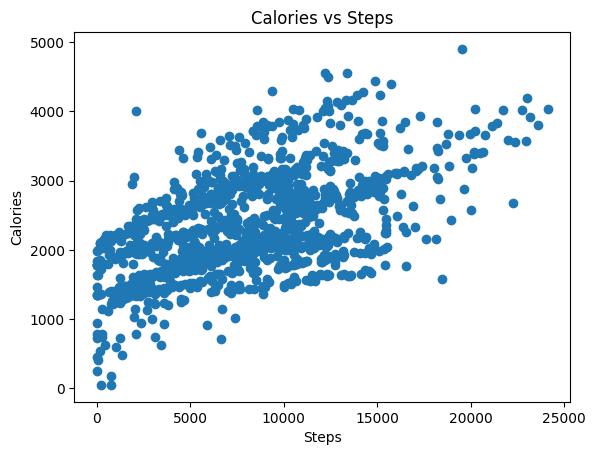

In [ ]:
plt.scatter(fitness.TotalSteps, fitness.Calories)
plt.xlabel("Steps")
plt.ylabel("Calories")
plt.title("Calories vs Steps")
plt.show()

In [ ]:
model_linear = bmb.Model("Calories ~ TotalSteps + VeryActiveMinutes + SedentaryMinutes", fitness)

idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True})

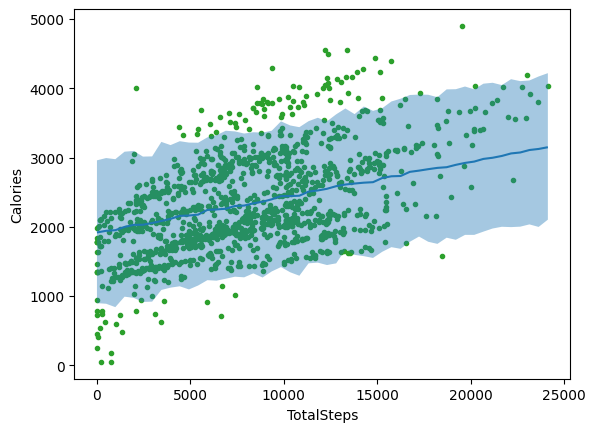

In [ ]:
bmb.interpret.plot_predictions(model_linear, idata_linear, "TotalSteps", pps=True)

plt.plot(fitness.TotalSteps,  fitness.Calories,  "C2.",  zorder=-3)

The model above showcases the linear predictor of Calories vs Total Steps

In [ ]:
model_poly = bmb.Model( "Calories ~ poly(TotalSteps, degree=3) + VeryActiveMinutes + SedentaryMinutes", fitness, family = "t")

idata_poly = model_poly.fit(idata_kwargs={"log_likelihood": True})

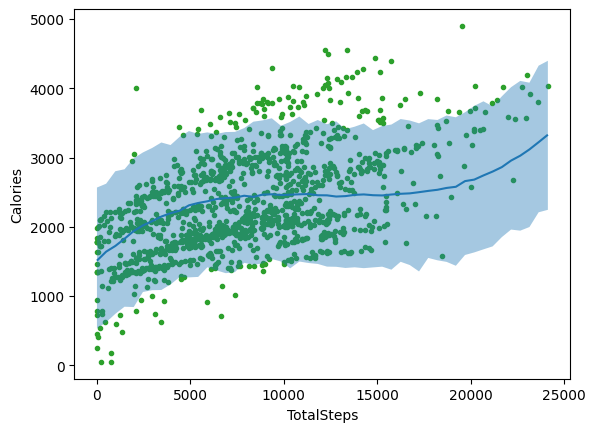

In [ ]:
bmb.interpret.plot_predictions(model_poly, idata_poly, "TotalSteps", pps=True)

plt.plot(fitness.TotalSteps, fitness.Calories,"C2.", zorder=-3)

The model above showcases the relationship between TotalSteps and Calories while utlizing postiive and negative effects of Active Minutes and the Sedentary ones.

In [ ]:
num_knots = 6

knots = np.linspace(fitness.TotalSteps.min(), fitness.TotalSteps.max(), num_knots + 2)[1:-1]

model_spline = bmb.Model( "Calories ~ bs(TotalSteps, degree=3, knots=knots) + VeryActiveMinutes + SedentaryMinutes", fitness)

idata_spline = model_spline.fit(idata_kwargs={"log_likelihood": True})


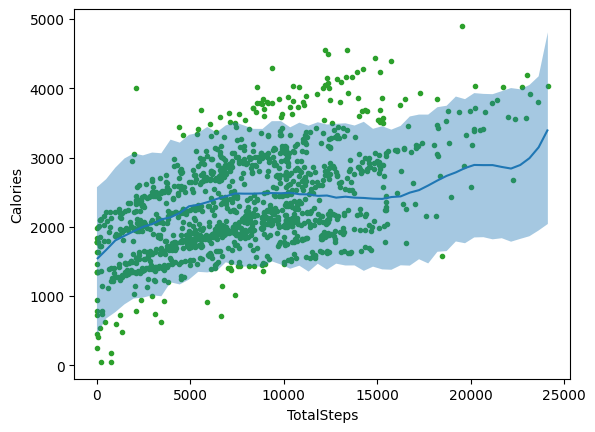

In [ ]:
bmb.interpret.plot_predictions(model_spline, idata_spline, "TotalSteps", pps=True)

plt.plot(fitness.TotalSteps, fitness.Calories, "C2.",zorder=-3)

The model above utilizes a b-spline with 6 knots in order to predict Calories through utilization of cubic curves between each break point (degree = 3). This also includes the positive and negative relationships between VeryActiveMinutes and Sedentary ones.

In [ ]:
cmp = az.compare({
    "Linear": idata_linear,
    "Polynomial": idata_poly,
    "Spline": idata_spline
})

cmp

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Polynomial,0,-9678.919522,7.287194,0.000000,0.563482,23.905674,0.000000,False,log
Spline,1,-9680.196494,13.220342,1.276972,0.361360,24.195356,2.748629,True,log
Linear,2,-9711.743976,5.603003,32.824454,0.075158,23.144745,8.671761,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

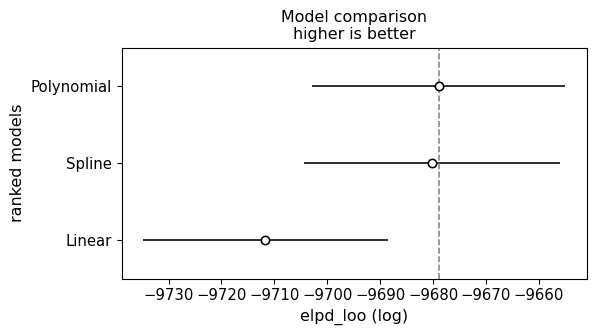

In [ ]:
az.plot_compare(cmp)

A cubic polynomial for steps + the two activity‑minute predictors gave me the best model to predict calories burned.